In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
df.shape

(100000, 9)

In [4]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


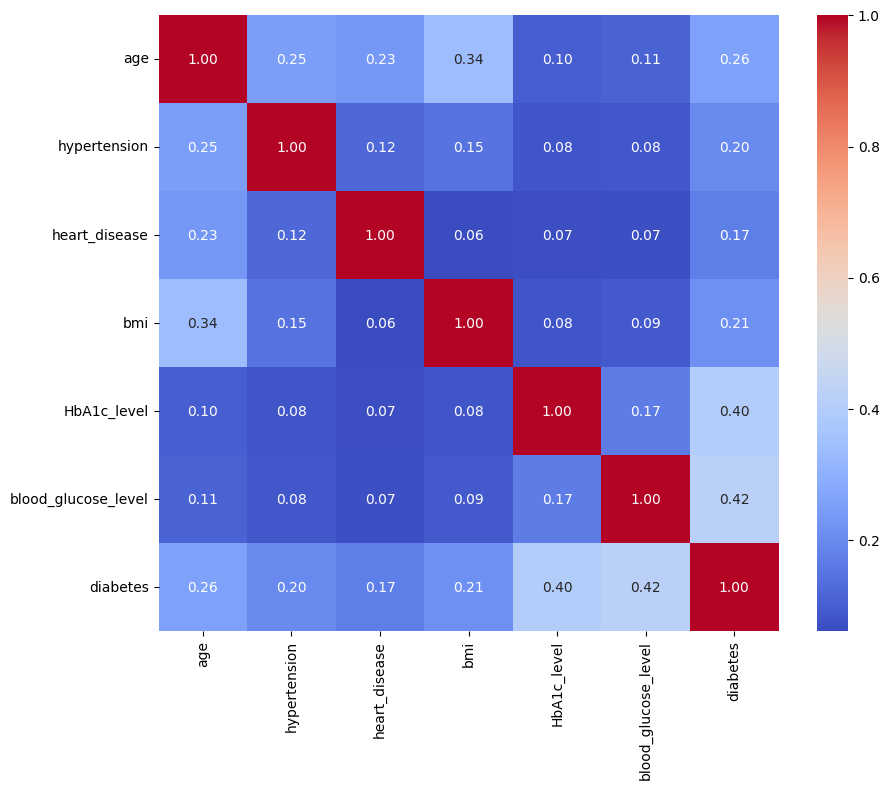

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [8]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False,drop='first')
encoded = encoder.fit_transform(df[['smoking_history','gender']])
encoded_df = pd.DataFrame(encoded,columns=encoder.get_feature_names_out(['smoking_history','gender']))

In [9]:
encoded_df.head()

,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Male,gender_Other
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [10]:
df.shape

(100000, 9)

In [11]:
df = df.drop(['gender','smoking_history'],axis=1)
df = pd.concat([df, encoded_df],axis=1)

In [12]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Male,gender_Other
0,80.0,0,1,25.19,6.6,140,0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,54.0,0,0,27.32,6.6,80,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,28.0,0,0,27.32,5.7,158,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,36.0,0,0,23.45,5.0,155,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,76.0,1,1,20.14,4.8,155,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [13]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current,gender_Male,gender_Other
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.00000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000,0.092860,0.040040,0.093520,0.35095,0.06447,0.414300,0.000180
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883,0.290238,0.196054,0.291161,0.47727,0.24559,0.492603,0.013415
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.00000,1.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.00000,1.000000,1.000000


In [14]:
df = df.drop_duplicates()

In [15]:
df.shape

(96146, 14)

In [16]:
X = df.drop('diabetes',axis=1)
y = df['diabetes']

In [17]:
y.value_counts()

diabetes
0    87664
1     8482
Name: count, dtype: int64

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [19]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
X_train_scale = ss.fit_transform(X_train)
X_test_scale = ss.transform(X_test)

In [20]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()
X_train_smote, y_train_smote = smote.fit_resample(X_train_scale, y_train)

In [21]:
y_train_smote.value_counts()

diabetes
0    61365
1    61365
Name: count, dtype: int64

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix

lr = LogisticRegression()
lr.fit(X_train_smote, y_train_smote)
y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_smote)


result =[]
print('train')
print(accuracy_score(y_train_smote, y_pred_train))
print(recall_score(y_train_smote, y_pred_train))
print(confusion_matrix(y_train_smote, y_pred_train))

print("-"*10,'test','-'*10)
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

result.append({
    'model':'logistic',
    'train accuracy': accuracy_score(y_train_smote, y_pred_train),
    'test accuracy': accuracy_score(y_test, y_pred),
    'train recall': recall_score(y_train_smote, y_pred_train),
    'test recall' : recall_score(y_test, y_pred)
})

train
0.8883484070724355
0.8878024932779272
[[54547  6818]
 [ 6885 54480]]
---------- test ----------
0.8840660102620995
0.8789783889980354
[[23263  3036]
 [  308  2237]]


In [23]:
from sklearn.naive_bayes import GaussianNB

naive = GaussianNB()
naive.fit(X_train_smote, y_train_smote)
y_pred = naive.predict(X_test_scale)
y_pred_train = naive.predict(X_train_smote)

print('train')
print(accuracy_score(y_train_smote, y_pred_train))
print(recall_score(y_train_smote, y_pred_train))
print(confusion_matrix(y_train_smote, y_pred_train))

print("-"*10,'test','-'*10)
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

result.append({
    'model':'naive bayes',
    'train accuracy': accuracy_score(y_train_smote, y_pred_train),
    'test accuracy': accuracy_score(y_test, y_pred),
    'train recall': recall_score(y_train_smote, y_pred_train),
    'test recall' : recall_score(y_test, y_pred)
})

train
0.5688340259105353
0.9998044487900268
[[ 8460 52905]
 [   12 61353]]
---------- test ----------
0.2148800443766468
1.0
[[ 3653 22646]
 [    0  2545]]


In [24]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

Ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                           n_estimators=201,
                           random_state=42
                           )
Ada.fit(X_train_smote, y_train_smote)
y_pred = Ada.predict(X_test_scale)
y_pred_train = Ada.predict(X_train_smote)

print('train')
print(accuracy_score(y_train_smote, y_pred_train))
print(recall_score(y_train_smote, y_pred_train))
print(confusion_matrix(y_train_smote, y_pred_train))

print("-"*10,'test','-'*10)
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

result.append({
    'model':'Ada boost',
    'train accuracy': accuracy_score(y_train_smote, y_pred_train),
    'test accuracy': accuracy_score(y_test, y_pred),
    'train recall': recall_score(y_train_smote, y_pred_train),
    'test recall' : recall_score(y_test, y_pred)
})

train
0.9403894728265297
0.9452130693391999
[[57411  3954]
 [ 3362 58003]]
---------- test ----------
0.9243516849258078
0.8463654223968566
[[24508  1791]
 [  391  2154]]


In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier()
param = [{
    'n_estimators':[101,201,301],
    'max_depth':[2,3,4],
    'min_samples_split':[2,3,4,5,6]
}]
grid = GridSearchCV(estimator=rf, param_grid=param, cv=5, n_jobs=3)
grid.fit(X_train_smote, y_train_smote)
y_pred = grid.predict(X_test_scale)
y_pred_train = grid.predict(X_train_smote)

print('train')
print(accuracy_score(y_train_smote, y_pred_train))
print(recall_score(y_train_smote, y_pred_train))
print(confusion_matrix(y_train_smote, y_pred_train))

print("-"*10,'test','-'*10)
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

result.append({
    'model':'random forest',
    'train accuracy': accuracy_score(y_train_smote, y_pred_train),
    'test accuracy': accuracy_score(y_test, y_pred),
    'train recall': recall_score(y_train_smote, y_pred_train),
    'test recall' : recall_score(y_test, y_pred)
})

train
0.9114560417175914
0.8909476085716613
[[57190  4175]
 [ 6692 54673]]
---------- test ----------
0.9202953820551935
0.8416502946954814
[[24403  1896]
 [  403  2142]]


In [26]:
from xgboost import XGBClassifier

xg = XGBClassifier(n_estimators=101)

xg.fit(X_train_smote, y_train_smote)
y_pred = xg.predict(X_test_scale)
y_pred_train = xg.predict(X_train_smote)

print('train')
print(accuracy_score(y_train_smote, y_pred_train))
print(recall_score(y_train_smote, y_pred_train))
print(confusion_matrix(y_train_smote, y_pred_train))

print("-"*10,'test','-'*10)
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

result.append({
    'model':'XGboost',
    'train accuracy': accuracy_score(y_train_smote, y_pred_train),
    'test accuracy': accuracy_score(y_test, y_pred),
    'train recall': recall_score(y_train_smote, y_pred_train),
    'test recall' : recall_score(y_test, y_pred)
})

train
0.9850973682066324
0.9719709932371873
[[61256   109]
 [ 1720 59645]]
---------- test ----------
0.9685896546942172
0.7021611001964636
[[26151   148]
 [  758  1787]]


In [27]:
results = pd.DataFrame(result)

In [28]:
results

,model,train accuracy,test accuracy,train recall,test recall
0,logistic,0.888348,0.884066,0.887802,0.878978
1,naive bayes,0.568834,0.214880,0.999804,1.000000
2,Ada boost,0.940389,0.924352,0.945213,0.846365
3,random forest,0.911456,0.920295,0.890948,0.841650
4,XGboost,0.985097,0.968590,0.971971,0.702161
